### Amanda Cutler

CUID: alc2282

## Final Project

**Data:** 
https://www.climatecentral.org/report/monthly-attribution-overview-march-2026  
NOAA ACIS API: Historical March mean temperatures (1970–2025) for the top 10 compound-extreme cities

**Context:** From December 2025 to February 2026, a ridge of high pressure associated with the negative phase of the Arctic Oscillation steered cold air into the eastern part of the U.S. while the western half was trapped in warm weather conditions ([Weather Channel](https://weather.com/news/weather/news/2026-03-02-meteorological-winter-2025-2026-west-warmest-on-record)). This contributed to exceptionally high temperatures across western cities in March 2026. Using NOAA’s Applied Climate Information System (ACIS) and the Climate Shift Index (CSI) tool, Climate Central estimated that 33 cities across 192 weather stations experienced their hottest March on record ([Excel](https://assets.ctfassets.net/cxgxgstp8r5d/1DTpkxi1aHaKZ007evCyL5/f891fb73cc0ae03c64e8e3b81b50eb52/Climate_Central_US_climate_summary_data_March_2026_all_csi_values_0_200.xlsx)).

**Question 1:** Was March 2026 a compound hot-dry extreme across U.S. cities, and which cities stood out the most relative to the national distribution of temperature and precipitation anomalies? 

**Question 2:** For the top 10 cities identified in Part 1, how does March 2026 compare to their own historical records? Was it spatially extreme *and* historically unprecedented?

**Hypothesis:** Because the U.S. West and Southwest are areas that often experience drought, my hypothesis is that the cities with the warmest March 2026 temperatures will be clustered in this region. I also predict that given rising global temperatures, March 2026 temperature and precipitaiton anomalies will be historically unprecedented for the top 10 cities identified in Part 1.

In [2]:
import os
os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/share/proj'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
from geopy.geocoders import Nominatim
import time

### Load Data

In [3]:
url = ('https://assets.ctfassets.net/cxgxgstp8r5d/1DTpkxi1aHaKZ007evCyL5/'
       'f891fb73cc0ae03c64e8e3b81b50eb52/'
       'Climate_Central_US_climate_summary_data_March_2026_all_csi_values_0_200.xlsx')

df = pd.read_excel(url, header=3)
df.head(3)

,City,State,Year data collection began for this station,Average Temperature March 2026 (°F),Temperature Anomaly March 2026 (°F) (difference from normal),Warming during March since 1970 (°F),Monthly Temperature Ranking on Record (since year data collection began),Precipitation March 2026 (inches),Percentage of precipitation compared to normal March rainfall (the 1991-2020 average),Monthly Precipitation Ranking on Record (since year data collection began),Maximum Daily CSI value reached,Number of Days Experiencing a CSI of 2 or higher,Number of Days Experiencing a CSI of 5,Number of Days Experiencing a CSI of 3 or higher,Number of Days Experiencing a CSI of 4 or higher,Number of Days Experiencing a CSI of -1 or lower,Number of Days Experiencing a CSI of -2 or lower,Number of Days Experiencing a CSI of -3 or lower,Number of Days Experiencing a CSI of -4 or lower,CSI of -5
0,Abilene,TX,1886,66.8,8.7,4.7,1,2.6,149%,20,3,17,0,5,0,0,0,0,0,0
1,Albany,GA,1893,64.2,3.9,5.8,15,2.6,60%,102,2,11,0,0,0,2,0,0,0,0
2,Albany,NY,1874,38.7,3.0,3.4,24,3.9,126%,34,3,6,0,2,0,1,0,0,0,0


### Preprocessing

In [4]:
#Rename columns

df = df.rename(columns={
    'City'                                                                                   : 'city',
    'State'                                                                                  : 'state',
    'Average Temperature March 2026 (\u00b0F)'                                               : 'avg_temp',
    'Temperature Anomaly March 2026 (\u00b0F) (difference from normal)'                      : 'temp_anom',
    'Warming during March since 1970 (\u00b0F)'                                               : 'warming_1970',
    'Monthly Temperature Ranking on Record (since year data collection began)'                : 'temp_rank',
    'Precipitation March 2026 (inches)'                                                      : 'precip_in',
    'Percentage of precipitation compared to normal March rainfall (the 1991-2020 average)'  : 'precip_pct_str',
    'Monthly Precipitation Ranking on Record (since year data collection began)'             : 'precip_rank',
    'Maximum Daily CSI value reached'                                                        : 'csi_max',
    'Number of Days Experiencing a CSI of 5'                                                 : 'csi5_days',
})

In [5]:
#Get rid of missing values
df = df.dropna(subset=['warming_1970']).reset_index(drop=True)

In [6]:
#Convert string to float
df['precip_pct'] = df['precip_pct_str'].str.replace('%', '').astype(float)

In [7]:
df.head(3)

,city,state,Year data collection began for this station,avg_temp,temp_anom,warming_1970,temp_rank,precip_in,precip_pct_str,precip_rank,...,Number of Days Experiencing a CSI of 2 or higher,csi5_days,Number of Days Experiencing a CSI of 3 or higher,Number of Days Experiencing a CSI of 4 or higher,Number of Days Experiencing a CSI of -1 or lower,Number of Days Experiencing a CSI of -2 or lower,Number of Days Experiencing a CSI of -3 or lower,Number of Days Experiencing a CSI of -4 or lower,CSI of -5,precip_pct
0,Abilene,TX,1886,66.8,8.7,4.7,1,2.6,149%,20,...,17,0,5,0,0,0,0,0,0,149.0
1,Albany,GA,1893,64.2,3.9,5.8,15,2.6,60%,102,...,11,0,0,0,2,0,0,0,0,60.0
2,Albany,NY,1874,38.7,3.0,3.4,24,3.9,126%,34,...,6,0,2,0,1,0,0,0,0,126.0


### Assign a Lat/Lon to each City, State

In [8]:
geolocator = Nominatim(user_agent='climate_project')

lats, lons = [], []
for _, row in df.iterrows():
    query = f"{row['city']}, {row['state']}, USA"
    try:
        loc = geolocator.geocode(query, timeout=10)
        lats.append(loc.latitude  if loc else np.nan)
        lons.append(loc.longitude if loc else np.nan)
    except:
        lats.append(np.nan)
        lons.append(np.nan)
    time.sleep(1)   

df['lat'] = lats
df['lon'] = lons
df = df.dropna(subset=['lat', 'lon']).reset_index(drop=True)
print(f'Geocoded: {len(df)} stations')

Geocoded: 193 stations


Save output to avoid running again:

In [ ]:
df.to_csv("Climate_Central_with_lat_lon.csv", index=False)

### Figure 1: Temperature and Precipitation Anomalies

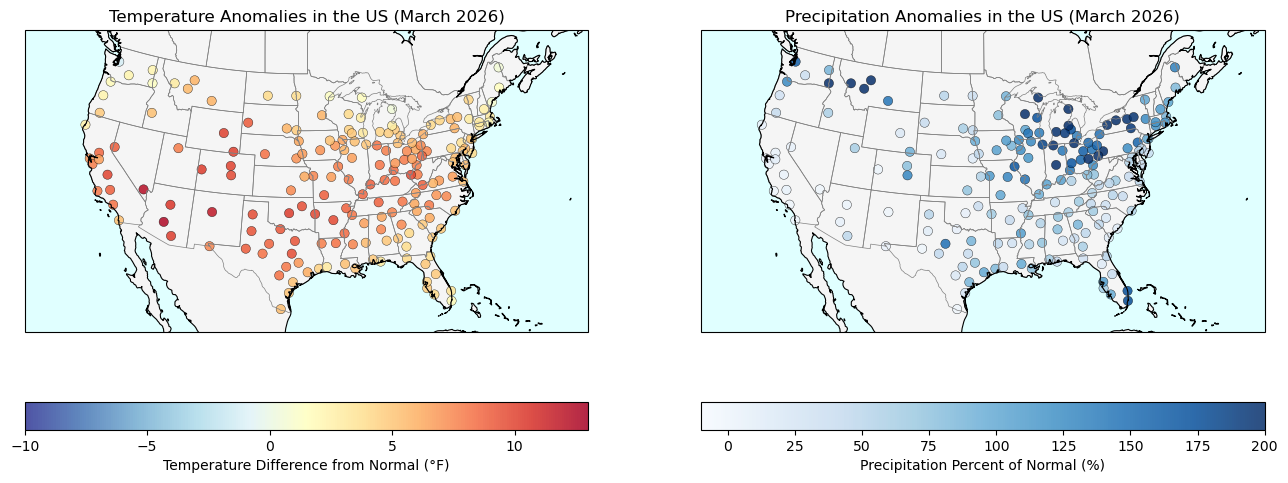

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         subplot_kw={'projection': ccrs.LambertConformal()})
extent = [-125, -66, 24, 50]

#Temperature
ax1 = axes[0]
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.LAND, facecolor='whitesmoke')
ax1.add_feature(cfeature.OCEAN, facecolor='lightcyan')
ax1.set_title('Temperature Anomalies in the US (March 2026)')

sc1 = ax1.scatter(df['lon'], df['lat'],
                  c=df['temp_anom'],s=45,
                  cmap='RdYlBu_r', vmin=-10, vmax=13, alpha=0.85, transform=ccrs.PlateCarree(),
                  edgecolors='k', linewidths=0.3)
plt.colorbar(sc1, ax=ax1, orientation='horizontal', label='Temperature Difference from Normal (\u00b0F)')

#Precipitation
ax2 = axes[1]
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.LAND, facecolor='whitesmoke')
ax2.add_feature(cfeature.OCEAN, facecolor='lightcyan')
ax2.set_title('Precipitation Anomalies in the US (March 2026)')

sc2 = ax2.scatter(df['lon'], df['lat'],
                  c=df['precip_pct'],s=45,
                  cmap='Blues', vmin=-10, vmax=200, alpha=0.85, transform=ccrs.PlateCarree(),
                  edgecolors='k', linewidths=0.3)
plt.colorbar(sc2, ax=ax2, orientation='horizontal', label='Precipitation Percent of Normal (%)')


These figures are using color to scale the temperature and precipitation anomalies for March 2026. High temperature anomalies are in the southwest U.S., and high precipitation anomalies are in the midwest.

### Figure 2: Cities with Compound Hot-Dry Extremes

To isolate the cities with the highest temperature differences from baseline and lowest precipitation percentages from baseline, both temperature and precipitation variables can be standardized into z-scores relative to the full national distribution. Constructing the signal as follows will mean that a high value is both hot and dry, as long as cities are only counted that are hotter and drier than the national norm, to avoid a city in MN, for example, having a high compound signal because its temperature did not increase by much but it received a lot of rain :

$$\text{Compound Signal} = Z_{\text{temp}} - Z_{\text{precip}}$$

In [10]:
df['z_temp']   = (df['temp_anom']  - df['temp_anom'].mean())  / df['temp_anom'].std()
df['z_precip'] = (df['precip_pct'] - df['precip_pct'].mean()) / df['precip_pct'].std()

#Only using cities that are hotter and drier than the national norm
df['z_temp_pos']   = df['z_temp'].clip(lower=0)
df['z_precip_neg'] = df['z_precip'].clip(upper=0)
df['compound'] = df['z_temp_pos'] - df['z_precip_neg']

print('\nTop 10 cities by compound signal:')
top10 = df.nlargest(10, 'compound')
print(top10[['city','state','compound']])


Top 10 cities by compound signal:
               city state  compound
92        Las Vegas    NV  3.033567
133         Phoenix    AZ  3.025113
3       Albuquerque    NM  2.920473
61        Flagstaff    AZ  2.526267
68   Grand Junction    CO  2.469719
125   Oklahoma City    OK  2.389769
66           Fresno    CA  2.371574
30           Casper    WY  2.186646
124          Odessa    TX  2.128813
187   Wichita Falls    TX  2.078760


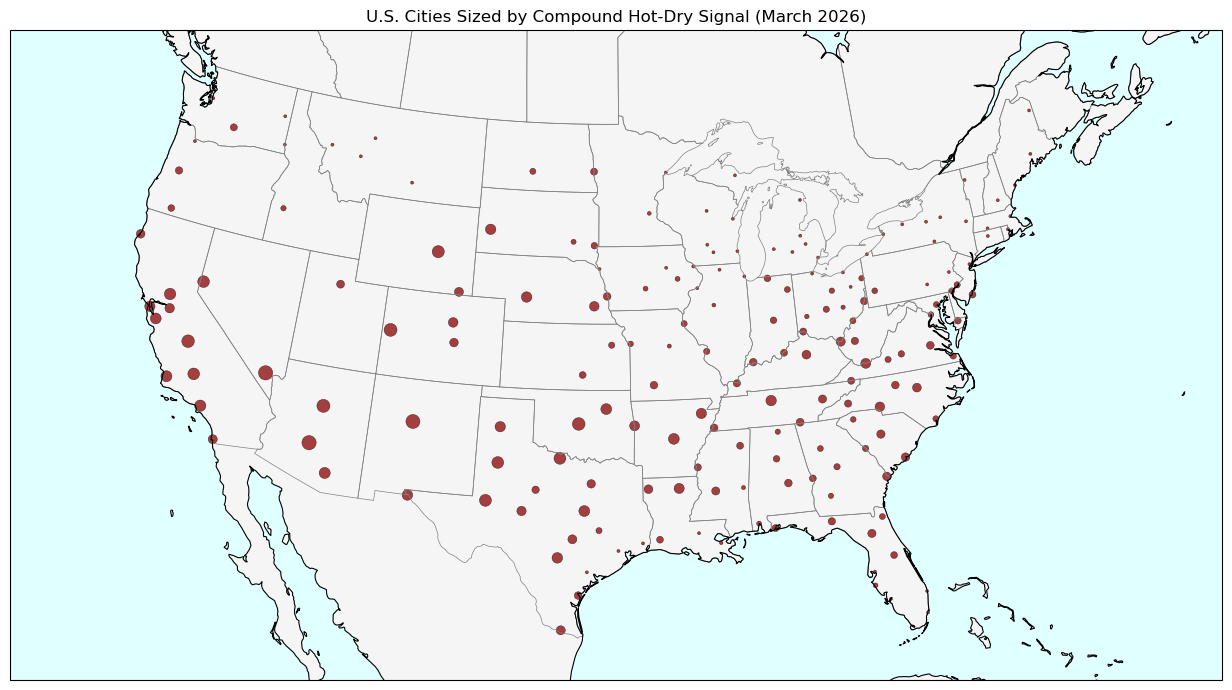

In [11]:
plt.figure(figsize=(13,7))
ax=plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='whitesmoke')
ax.add_feature(cfeature.OCEAN, facecolor='lightcyan')

sizes = (df['compound']* 35).clip(lower=5)
ax.scatter(df['lon'],df['lat'], s=sizes, color='darkred', alpha=0.75, transform=ccrs.PlateCarree(),edgecolors='k',
           linewidths=0.3)
ax.set_title('U.S. Cities Sized by Compound Hot-Dry Signal (March 2026)')
plt.tight_layout()
plt.show()

The cities with the largest hot-dry signals, are located in the West and Southwest, confirming Part 1 of my hypothesis.

### Figure 3: Temporal Analysis of Top 10 Hot-Dry Cities

In [12]:
top10 = df.nlargest(10, 'compound').reset_index(drop=True)
print(top10[['city', 'state', 'lat', 'lon']])

             city state        lat         lon
0       Las Vegas    NV  36.167426 -115.148413
1         Phoenix    AZ  33.448437 -112.074141
2     Albuquerque    NM  35.084103 -106.650985
3       Flagstaff    AZ  35.198752 -111.651822
4  Grand Junction    CO  39.067257 -108.564480
5   Oklahoma City    OK  35.472989  -97.517054
6          Fresno    CA  36.739442 -119.784830
7          Casper    WY  42.850119 -106.325138
8          Odessa    TX  31.845715 -102.367687
9   Wichita Falls    TX  33.900457  -98.502078


In [13]:
#Hardcode station IDs for top 10 hot-dry cities
station_ids = {
    'Las Vegas'     : '23169',  # Harry Reid Intl AP
    'Phoenix'       : '23183',  # Phoenix Sky Harbor
    'Albuquerque'   : '23050',  # Albuquerque Intl AP
    'Flagstaff'     : '03103',  # Flagstaff Pulliam AP
    'Grand Junction': '23066',  # Grand Junction Regional AP
    'Oklahoma City' : '13967',  # Oklahoma City Will Rogers
    'Fresno'        : '93193',  # Fresno Yosemite Intl AP
    'Casper'        : '24089',  # Casper/Natrona AP
    'Odessa'        : '03031',  # Midland Intl AP (closest to Odessa)
    'Wichita Falls' : '13966',  # Wichita Falls Municipal AP
}

In [14]:
def get_march_history_acis(station_id):

    url = "http://data.rcc-acis.org/StnData"
    request = {
        "sid": station_id,
        "sdate": "1970-01-01",
        "edate": "2026-12-31",
        "elems": [{"name": "avgt", "interval": "dly"}],
        "output": "json"
    }

    response = requests.post(url, json=request)
    data = response.json()["data"]
    
    df_hist = pd.DataFrame(data, columns=["date", "temp"])
    df_hist["date"] = pd.to_datetime(df_hist["date"])
    df_hist["temp"] = pd.to_numeric(
        df_hist["temp"],
        errors="coerce"
    )
    df_hist["year"] = df_hist["date"].dt.year
    df_hist["month"] = df_hist["date"].dt.month

    # Keep only March
    df_hist = df_hist[df_hist["month"] == 3]

    # Mean March temperature each year
    march_means = df_hist.groupby("year")["temp"].mean()

    return march_means

In [15]:
historical = {}

for i, row in top10.iterrows():
    
    city = row["city"]
    state = row["state"]
    label = city + ", " + state
    station_id = station_ids[city]
    historical[label] = get_march_history_acis(station_id)
    print("Downloaded:", label)
    time.sleep(1)

Downloaded: Las Vegas, NV
Downloaded: Phoenix, AZ
Downloaded: Albuquerque, NM
Downloaded: Flagstaff, AZ
Downloaded: Grand Junction, CO
Downloaded: Oklahoma City, OK
Downloaded: Fresno, CA
Downloaded: Casper, WY
Downloaded: Odessa, TX
Downloaded: Wichita Falls, TX


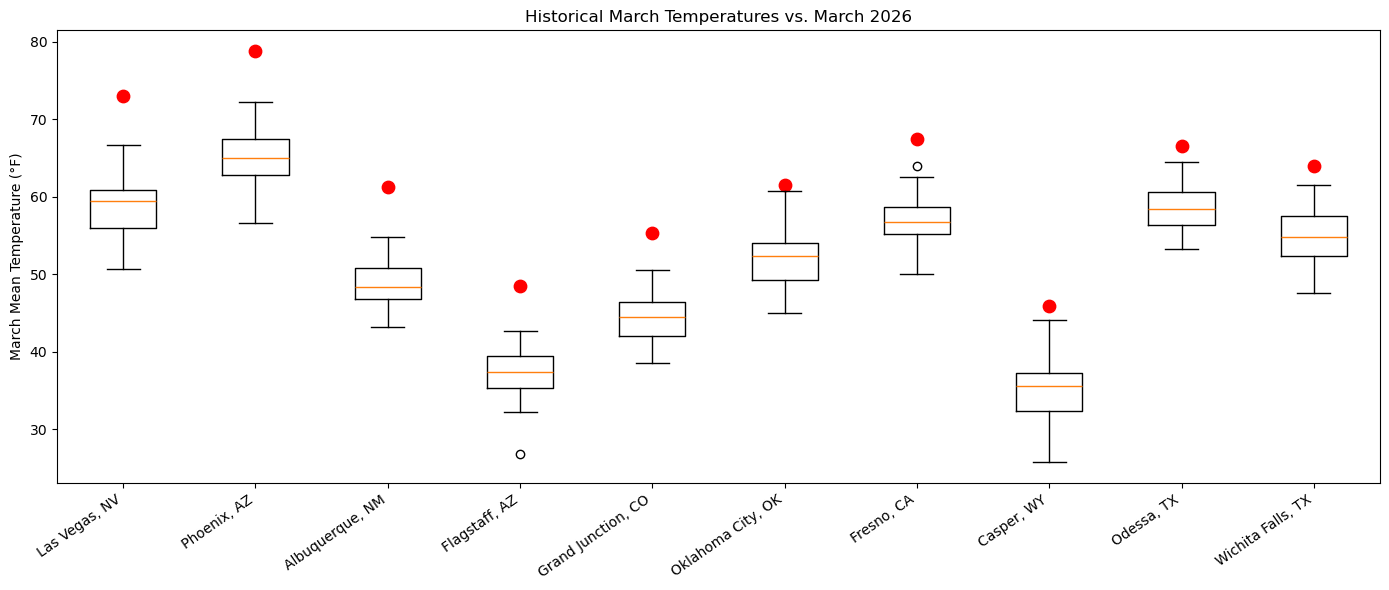

In [16]:
city_labels = []
hist_data = []
march2026_vals = []

for label, series in historical.items():
    hist = series[series.index < 2026].dropna()
    val_2026 = series.get(2026, np.nan)

    if len(hist) > 5:
        city_labels.append(label)
        hist_data.append(hist)
        march2026_vals.append(val_2026)

plt.figure(figsize=(14, 6))
plt.boxplot(hist_data)

for i, val in enumerate(march2026_vals):
    plt.scatter(i + 1, val, color='red', s=80)

plt.xticks(
    range(1, len(city_labels) + 1),
    city_labels,
    rotation=35,
    ha='right'
)

plt.ylabel('March Mean Temperature (°F)')
plt.title('Historical March Temperatures vs. March 2026')

plt.tight_layout()
plt.show()

This is confirming Part 2 of my hypothesis, that March 2026 temperatures were hotter than historical March temperatures for each city, but I'm surprised by the extent to which the red dot, representing the average temperature for March 2026, lies outside each city's box plot. It is not only slightly above the historical average, but an extreme outlier in each case. Interestingly enough, Fresno has another high March outlier, and Flagstaff has a low March outlier. 

### Figure 4: March 2026 was hotter than historical March mean temperatures - but by how much?

In [17]:
record_rows = []

for city, temps in historical.items():
    hist = temps[temps.index < 2026].dropna()
    temp_2026 = temps[2026]
    previous_record = hist.max()
    degrees_above = temp_2026 - previous_record
    city_name = city.split(',')[0]
    state_name = city.split(',')[1].strip()

    compound_value = top10.loc[
        (top10['city'] == city_name) &
        (top10['state'] == state_name),
        'compound'
    ].values[0]

    record_rows.append({
        'city': city,
        'degrees_above_record': degrees_above,
        'compound': compound_value
    })

record_df = pd.DataFrame(record_rows)

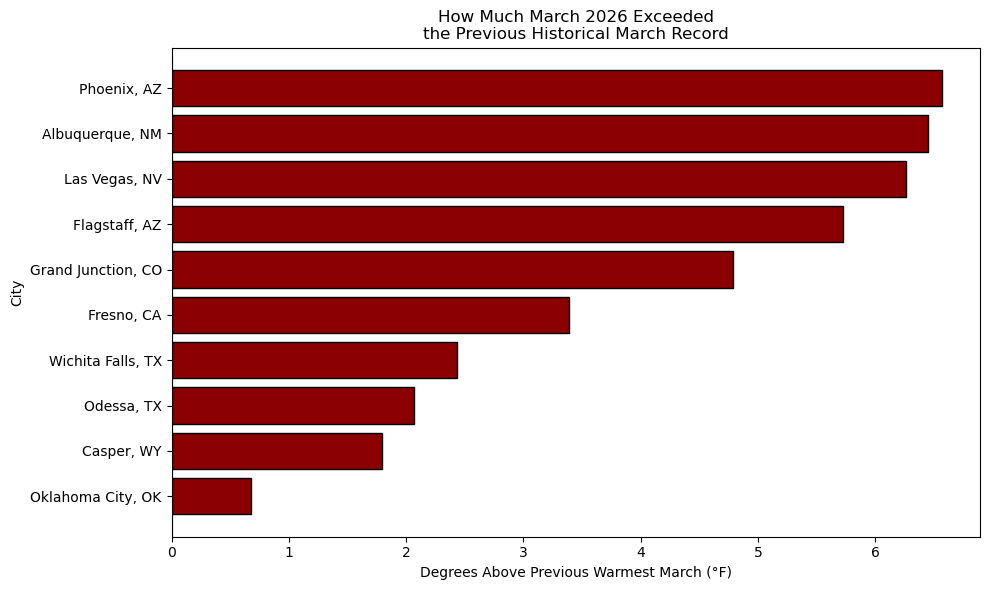

In [18]:
record_df = record_df.sort_values(
    'degrees_above_record',
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    record_df['city'],
    record_df['degrees_above_record'],
    color='darkred',
    edgecolor='black'
)

plt.axvline(0, color='black')
plt.xlabel('Degrees Above Previous Warmest March (°F)')
plt.ylabel('City')
plt.title(
    'How Much March 2026 Exceeded\n'
    'the Previous Historical March Record'
)

plt.tight_layout()
plt.show()

Record exceedance was highest for Phoenix, Albuquerque, and Las Vegas, by over 6 degrees, which is an alarming amount of warming for a single year.

### Summary:

To answer the research questions, spatially, March 2026 was a compound hot-dry extreme concentrated in the southwest U.S. Temporally, for each of the 10 cities that demonstrated the highest compound hot-dry signal, this was not only an extremely warm month, but an all time record, exceeding the previous record by more than 6 degrees in the case of Phoenix, Albuquerque, and Las Vegas.

Some limitations include 1) the fact that the NOAA ACIS airport weather station data may not be representative of conditions throughout each city, particularly for areas like Flagstaff that are also influenced by complex local topography, 2) that the analysis was for monthly March data and ignored seasonal patterns, and 3) the cities in the dataset are not evenly distributed and gaps remain. Also, the compound signal formula was an extreme simplification and joint probability methods would be more appropriate, though outside the scope of this course.

Future analysis could compare the geographic structure of temperature and precipitation anomalies with the ridge of high pressure associated with the negative Arctic Oscillation phase and look at the correlation between them. Understanding the co-occurence of heat and low precipitation is important for climate adaptation planning and water resource management in the southwest U.S. as compound hazards increase with climate change.